In [52]:
from google.colab import files
uploaded = files.upload()

Saving accident_prediction_india.csv to accident_prediction_india (5).csv


In [53]:
!pip install folium geopy

In [ ]:
import pandas as pd

df = pd.read_csv("accident_prediction_india.csv")
df.head()

,State Name,City Name,Year,Month,Day of Week,Time of Day,Accident Severity,Number of Vehicles Involved,Vehicle Type Involved,Number of Casualties,...,Road Type,Road Condition,Lighting Conditions,Traffic Control Presence,Speed Limit (km/h),Driver Age,Driver Gender,Driver License Status,Alcohol Involvement,Accident Location Details
0,Jammu and Kashmir,Unknown,2021,May,Monday,1:46,Serious,5,Cycle,0,...,National Highway,Wet,Dark,Signs,61,66,Male,NaN,Yes,Curve
1,Uttar Pradesh,Lucknow,2018,January,Wednesday,21:30,Minor,5,Truck,5,...,Urban Road,Dry,Dusk,Signs,92,60,Male,NaN,Yes,Straight Road
2,Chhattisgarh,Unknown,2023,May,Wednesday,5:37,Minor,5,Pedestrian,6,...,National Highway,Under Construction,Dawn,Signs,120,26,Female,NaN,No,Bridge
3,Uttar Pradesh,Lucknow,2020,June,Saturday,0:31,Minor,3,Bus,10,...,State Highway,Dry,Dark,Signals,76,34,Female,Valid,Yes,Straight Road
4,Sikkim,Unknown,2021,August,Thursday,11:21,Minor,5,Cycle,7,...,Urban Road,Wet,Dusk,Signs,115,30,Male,NaN,No,Intersection


In [ ]:
from geopy.geocoders import Nominatim
import time

geolocator = Nominatim(user_agent="geoapi")

# Get unique city-state pairs
unique_locations = df[['City Name', 'State Name']].drop_duplicates()

location_dict = {}

def get_lat_lon(city, state):
    try:
        location = geolocator.geocode(f"{city}, {state}, India")
        if location:
            return location.latitude, location.longitude
    except:
        pass
    return None, None

# Loop only unique values (FAST)
for _, row in unique_locations.iterrows():
    city = row['City Name']
    state = row['State Name']

    lat, lon = get_lat_lon(city, state)
    location_dict[(city, state)] = (lat, lon)

    time.sleep(1)  # still safe, but MUCH fewer calls

# Map back to full dataset
df['lat'] = df.apply(lambda row: location_dict[(row['City Name'], row['State Name'])][0], axis=1)
df['lon'] = df.apply(lambda row: location_dict[(row['City Name'], row['State Name'])][1], axis=1)

In [ ]:
import folium

# 🔥 REMOVE rows with missing coordinates
df = df.dropna(subset=['lat', 'lon'])

m3 = folium.Map(location=[22.5, 78.9], zoom_start=5)

for _, row in df.iterrows():
    color = 'green'
    if row['Accident Severity'] == 2:
        color = 'orange'
    elif row['Accident Severity'] == 3:
        color = 'red'

    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=6,
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=f"""
        City: {row['City Name']} <br>
        State: {row['State Name']} <br>
        Severity: {row['Accident Severity']} <br>
        Speed: {row['Speed Limit (km/h)']}
        """
    ).add_to(m3)

m3

In [ ]:
top_state = df['State Name'].value_counts().head(5)
print("\nTop States with Maximum Accidents:\n")
print(top_state)


Top States with Maximum Accidents:

State Name
Delhi         108
Kerala        102
Tamil Nadu    101
Gujarat       100
Karnataka      95
Name: count, dtype: int64


In [ ]:
# Define regions
north = ["Jammu and Kashmir","Himachal Pradesh","Punjab","Haryana","Delhi","Uttarakhand","Uttar Pradesh","Chandigarh"]
south = ["Tamil Nadu","Kerala","Karnataka","Andhra Pradesh","Telangana","Puducherry"]
east = ["Bihar","Jharkhand","West Bengal","Odisha","Sikkim"]
west = ["Rajasthan","Gujarat","Maharashtra","Goa","Madhya Pradesh","Chhattisgarh"]

# Function to assign region
def get_region(state):
    if state in north:
        return "North"
    elif state in south:
        return "South"
    elif state in east:
        return "East"
    elif state in west:
        return "West"
    else:
        return "Other"

# Create new column
df["Region"] = df["State Name"].apply(get_region)

# Count accidents by region
region_counts = df["Region"].value_counts()

print("Accident Count by Region:\n")
print(region_counts)

# Print states region-wise
print("\nStates in each region:\n")

print("North India States:")
for s in north:
    print(s)

print("\nSouth India States:")
for s in south:
    print(s)

print("\nEast India States:")
for s in east:
    print(s)

print("\nWest India States:")
for s in west:
    print(s)

Accident Count by Region:

Region
North    387
South    386
West     365
East     187
Other    186
Name: count, dtype: int64

States in each region:

North India States:
Jammu and Kashmir
Himachal Pradesh
Punjab
Haryana
Delhi
Uttarakhand
Uttar Pradesh
Chandigarh

South India States:
Tamil Nadu
Kerala
Karnataka
Andhra Pradesh
Telangana
Puducherry

East India States:
Bihar
Jharkhand
West Bengal
Odisha
Sikkim

West India States:
Rajasthan
Gujarat
Maharashtra
Goa
Madhya Pradesh
Chhattisgarh


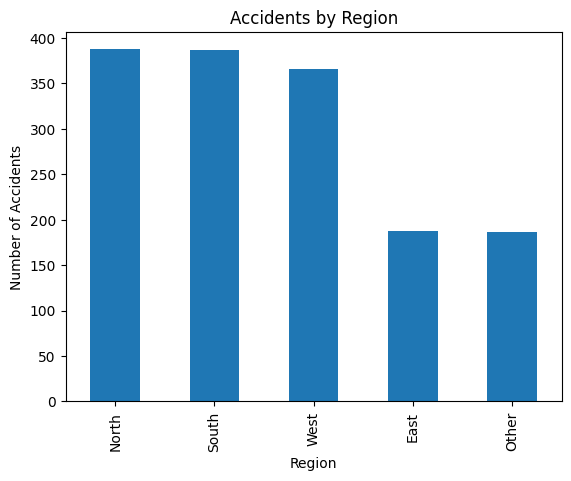

In [ ]:
import matplotlib.pyplot as plt

region_counts.plot(kind='bar')
plt.title("Accidents by Region")
plt.xlabel("Region")
plt.ylabel("Number of Accidents")
plt.show()

In [ ]:
top_time = df['Time of Day'].value_counts()
print("\nAccidents by Time of Day:\n")
print(top_time)


Accidents by Time of Day:

Time of Day
7:21     5
22:37    5
6:32     5
8:12     5
3:40     5
        ..
6:7      1
13:57    1
20:54    1
22:20    1
10:53    1
Name: count, Length: 956, dtype: int64


In [ ]:
weather = df['Weather Conditions'].value_counts()
print("\nAccidents by Weather:\n")
print(weather)


Accidents by Weather:

Weather Conditions
Rainy     330
Hazy      317
Stormy    297
Clear     289
Foggy     278
Name: count, dtype: int64


In [ ]:
road = df['Road Type'].value_counts()
print("\nAccidents by Road Type:\n")
print(road)


Accidents by Road Type:

Road Type
Village Road        402
State Highway       385
Urban Road          370
National Highway    354
Name: count, dtype: int64


In [ ]:
severity = df['Accident Severity'].value_counts()
print("\nSeverity Distribution:\n")
print(severity)


Severity Distribution:

Accident Severity
Minor      515
Fatal      501
Serious    495
Name: count, dtype: int64


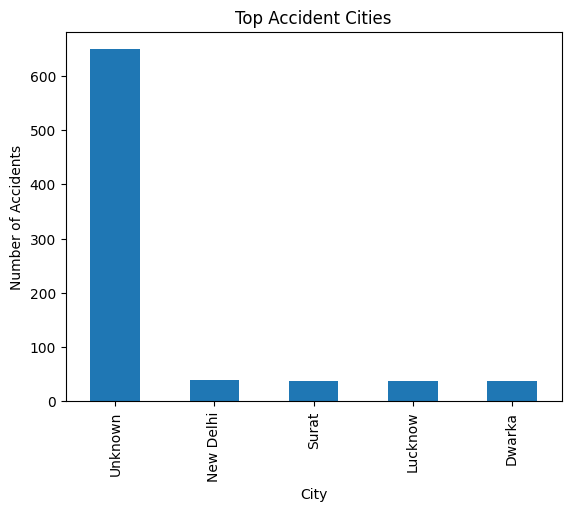

In [ ]:
import matplotlib.pyplot as plt

top_city.head(5).plot(kind='bar')
plt.title("Top Accident Cities")
plt.xlabel("City")
plt.ylabel("Number of Accidents")
plt.show()

In [ ]:
high_risk = df[df['Accident Severity'] == 3]

print("\nHigh Risk Conditions:\n")
print(high_risk[['City Name','Weather Conditions','Road Type']].head())


High Risk Conditions:

Empty DataFrame
Columns: [City Name, Weather Conditions, Road Type]
Index: []
